# Week 6 – Metrics, Norms and Topology

In AI, we often need to reason about similarity and proximity, but “objects” can take many forms:

* **Data points** – features in Euclidean or learned embedding spaces; distances determine neighbors, clusters, or anomaly scores.

* **Functions** – neural networks or policies approximate unknown mappings; norms over function spaces measure approximation error.

* **Probability distributions** – generative models, Bayesian inference, or reinforcement learning involve distances between distributions (e.g., KL-divergence, Wasserstein distance).

Despite the diversity of these objects, the unifying theme is that we work on a set equipped with a notion of distance between its elements. Understanding abstract metric properties allows us to design algorithms that:

- Compare and cluster entities of various types,
- Measure **approximation quality**,
- Guide sampling and optimization in high-dimensional or structured spaces.

## Metric spaces 

A **metric space** is a set $M$ together with a function $d: M \times M \to \mathbb{R}$ satisfying the following for all $x, y, z \in M$:

1. **Non-negativity:** $d(x, y) \ge 0$  
   *Distance is never negative.*
2. **Identity of indiscernibles:** $d(x, y) = 0$ iff $x = y$
  
3. **Symmetry:** $d(x, y) = d(y, x)$

4. **Triangle inequality:** $d(x, z) \le d(x, y) + d(y, z)$  

> The pair $(M, d)$ is called a **metric space**.


**Subspace:** Let $(M, d)$ be a metric space and $A \subseteq M$. The induced metric on $A$ is  
$$
d_A(x, y) = d(x, y), \quad \forall x, y \in A
$$  
Then $(A, d_A)$ is also a metric space.  

**Product of metric spaces:** Let $(M_i, d_i)$ be a collection of metric spaces indexed by $I$. For $x = (x_i)_{i \in I}, y = (y_i)_{i \in I}$ define the product metric:  
$$
d(x, y) = \sup_{i \in I} d_i(x_i, y_i)
$$  

**Example:** Multi-modal embeddings (image + text) use combined metrics over different feature spaces.

Product distances from emb1:
emb1 -> emb2 = 5.00
emb1 -> emb3 = 4.00


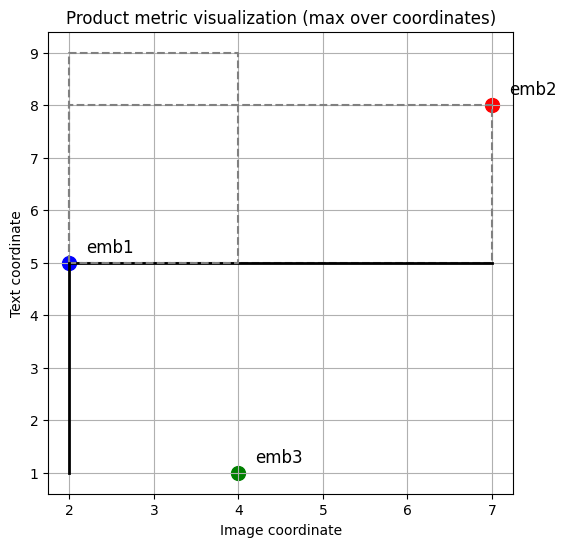

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Two embeddings in two modalities
# -----------------------------
# Embeddings: (image coordinate, text coordinate)
emb1 = np.array([2, 5])
emb2 = np.array([7, 8])
emb3 = np.array([4, 1])

def product_metric(a, b):
    # max distance over the two coordinates
    return max(abs(a[0]-b[0]), abs(a[1]-b[1]))

# Compute distances from emb1
print("Product distances from emb1:")
for i, emb in enumerate([emb2, emb3], start=2):
    print(f"emb1 -> emb{i} = {product_metric(emb1, emb):.2f}")

# -----------------------------
# Visualization
# -----------------------------
fig, ax = plt.subplots(figsize=(6,6))

embeddings = [emb1, emb2, emb3]
colors = ['blue', 'red', 'green']
labels = ['emb1', 'emb2', 'emb3']

# Plot embeddings
for i, emb in enumerate(embeddings):
    ax.scatter(emb[0], emb[1], c=colors[i], s=100)
    ax.text(emb[0]+0.2, emb[1]+0.2, labels[i], fontsize=12)

# Draw product metric "rectangles" to show max distance
def draw_product_box(a, b):
    # Draw a rectangle with sides = dx and dy
    dx = abs(a[0]-b[0])
    dy = abs(a[1]-b[1])
    max_side = max(dx, dy)
    # Rectangle coordinates
    rect_x = [a[0], a[0], a[0]+dx, a[0]+dx, a[0]]
    rect_y = [a[1], a[1]+dy, a[1]+dy, a[1], a[1]]
    ax.plot(rect_x, rect_y, linestyle='--', color='gray')
    # Show max distance as bold line
    if dx >= dy:
        ax.plot([a[0], b[0]], [a[1], a[1]], 'k-', lw=2)
    else:
        ax.plot([a[0], a[0]], [a[1], b[1]], 'k-', lw=2)

draw_product_box(emb1, emb2)
draw_product_box(emb1, emb3)

ax.set_xlabel("Image coordinate")
ax.set_ylabel("Text coordinate")
ax.set_title("Product metric visualization (max over coordinates)")
ax.grid(True)
plt.show()

#### Topology

**Balls:** In $(M, d)$, a ball of radius $r>0$ centered at $x$ is  
$$
B_r(x) = \{y \in M : d(x, y) < r\}
$$

**AI example:** k-NN search considers neighbors within a radius in feature space.

**Exercise 1:** Can a sphere of radius 3 in a metric space be a proper subset of a sphere of radius 2?  

**Exercise 2:** Show that if a sphere of radius 5 in a metric space is contained within a sphere of radius 2, then the two spheres must be identical.

**Exercise 3:** Let $f:\mathbb{R}\to\mathbb{R}$ be a strictly monotonic function. Define

$$
d:\mathbb{R}\times\mathbb{R}\to [0,\infty),\quad (x,y)\mapsto |f(x)-f(y)|.
$$

Show that $d$ satisfies the properties of a metric.

**Exercise 4:** Consider the metric on $\mathbb{R}$ defined by

$$
d:\mathbb{R}\times\mathbb{R}\to [0,\infty),\quad (x,y)\mapsto |2^x - 2^y|.
$$

Determine the elements of the open balls $B_1(0)$ and $B_2(1)$, moreover sketch these balls on the real line.


**Dense sets:** A subset $D \subseteq M$ is called **dense** in $M$ if every point $x \in M$ is either in $D$ or is a limit point of $D$, meaning that for every $r > 0$, $B_r(x) \cap D \neq \emptyset$.

**Neighborhood:** U is a neighborhood of $x \in M$ if $U$ contains a ball $B_r(x)$ for some $r>0$.

**Limit point:** $x \in M$ is a limit point of $A \subseteq M$ if every $B_r(x)$ contains a point of $A$ distinct from $x$:  
$$
x \text{ is a limit point of } A \iff \forall r>0, \exists y \in A: y \neq x \text{ and } d(x, y) < r
$$  
Denote the set of limit points as $A'$. 

#### Separability 

A metric space $(X,d)$ is called **separable** if it contains a countable dense subset, that is, a sequence $(f_n)_{n\in\mathbb{N}} \subset X$ such that every $g \in X$ can be approximated arbitrarily well. More precisely, for every $\varepsilon > 0$ there exists an index $n^*$ such that  
$$
d(f_{n^*}, g) < \varepsilon.
$$

**Intuition:** 
- Dense sets are those from which every point in the space can be well-approximated.
- Our later universal approximation theorems are precisely about the fact that certain classes of functions form a dense set in a suitably chosen function space.


#### Convergence, Limit, Continuity

Let $(X,d)$ be a metric space.  

- A sequence $(x_n)_{n\in\mathbb{N}}$ **converges** to $x\in X$ if  
  $$
  d(x_n, x) \to 0 \quad \text{as } n \to \infty.
  $$

- Let $(Y,\rho)$ be another metric space. The **limit** of a function $f:X\to Y$ at a point $x\in X$ is $y\in Y$ if, for every sequence $(x_n)_{n\in\mathbb{N}}$ in the domain of $f$ that converges to $x$, we have  
  $$
  x_n \to x \implies f(x_n) \to y.
  $$

- A function $f$ is **continuous** at $x_0\in X$ if  
  1. $f$ is defined at $x_0$, and  
  2. $f(x) \to f(x_0)$ as $x \to x_0$.

#### Equivalence of Metrics

Suppose that two metrics $d_1$ and $d_2$ are defined on a set $X$.  

- The metrics $d_1$ and $d_2$ are called **equivalent** if there exist constants $c_1, c_2 > 0$ such that  
  $$
  c_1\, d_1(x,y) \le d_2(x,y) \le c_2\, d_1(x,y), \quad x,y \in X.
  $$

- The metric $d_2$ is called **stronger** than $d_1$ if every sequence that converges in $(X, d_2)$ also converges in $(X, d_1)$.  
  In a weaker metric, it is “easier” for a sequence to be convergent.

**Exercise 5:** Show that the $L^2([0,1])$ metric is stronger than the $L^1([0,1])$ metric, and that the metric of $C([0,1])$ is stronger than both.

#### Lipschitz Functions 

A function $f : X \to Y$ between metric spaces is called **Lipschitz** if there exists a constant $L > 0$ such that  
$$
d_Y\big(f(x_1), f(x_2)\big) \le L \, d_X(x_1, x_2), \quad x_1, x_2 \in X.
$$  
The constant $L$ is called the **Lipschitz constant**.

- The Lipschitz property is similar to differentiability, but weaker; at the same time, it is stronger than continuity, and it is well-defined in general metric spaces.
- If $X = Y$ and $f$ is Lipschitz with constant $0 < L < 1$, then $f$ is called a **contraction**.

**Remark:** The Lipschitz property is a fundamental concept for understanding the behavior of AI algorithms. The Lipschitz constant quantifies the sensitivity of a model with respect to its inputs: the larger it is, the more strongly small changes in the input can affect the output. 

In the context of AI, Lipschitz continuity plays an important role in several areas:
- Lipschitz constants are closely related to key properties of neural networks, such as robustness, fairness, and generalization.
- We will see that in stochastic optimization algorithms used for training models, the Lipschitz property of the update function is a natural assumption. It is essential for proving convergence results and guarantees that ensure the reliability and stability of these algorithms.

**Exercise 6:** Show that $F(f) = \int_a^b f(x) \, dx$, $F: C[a, b] \to \mathbb{R}$, is Lipschitz with $K = b - a$. 

**Exercise 7:** Given a nonempty set $A \subset M$ and $x \in M$, define the distance between them by $d(x, A) = \inf\{d(x, a) : a \in A\}$. Show that $|d(x, A) - d(y, A)| \leq d(x, y)$, i.e., $d(x, A): M \to \mathbb{R}_+$ is Lipschitz with $K = 1$.

**Exercise 8:** Consider the mapping 
$$
T(g)(x) = \int_0^x g(t) \, dt : C[0, 1] \to C[0, 1].
$$
Show that $T$ is not a contraction, but $T^2$ is a contraction. What is a fixed point of $T$?

#### Worked Example: Estimating Lipschitz Constants for Function Compositions and ReLU Networks

Let $f:\mathbb{R}^n \to \mathbb{R}^m$ be a linear function $f(x) = A x + b$, where $A \in \mathbb{R}^{m \times n}$, $b \in \mathbb{R}^m$, and let $g:\mathbb{R}^m \to \mathbb{R}^m$ be the ReLU activation, $g(x)_i = \max(0, x_i)$. Define the composition $h = g \circ f$.

---

##### 1. Lipschitz constant of the linear part

The linear function is Lipschitz with the spectral norm of $A$:
$$
\|f(x) - f(y)\|_2 = \|A(x - y)\|_2 \le \|A\|_2 \, \|x - y\|_2
$$
so
$$
L_f = \|A\|_2
$$

---

##### 2. Lipschitz constant of ReLU

ReLU is applied component-wise and is 1-Lipschitz:
$$
\|g(u) - g(v)\|_2 \le \|u - v\|_2 \quad \forall u,v \in \mathbb{R}^m
$$
so
$$
L_g = 1
$$

---

##### 3. Lipschitz constant of the composition

For $h = g \circ f$:
$$
\|h(x) - h(y)\|_2 = \|g(f(x)) - g(f(y))\|_2 \le L_g \|f(x) - f(y)\|_2 \le L_g L_f \|x - y\|_2
$$
$$
\implies L_h \le L_g L_f = \|A\|_2
$$

---

##### 4. Multi-layer ReLU network

For an $L$-layer ReLU network:
$$
h(x) = g_L \circ f_L \circ \dots \circ g_1 \circ f_1 (x), \quad f_\ell(x) = A_\ell x + b_\ell
$$
with ReLU activations $g_\ell$, the overall Lipschitz constant is bounded by:
$$
L_h \le \prod_{\ell=1}^L \|A_\ell\|_2
$$

---

##### 5. Example with concrete matrices

Let
$$
A_1 = \begin{bmatrix}1 & 2\\ -1 & 1\end{bmatrix}, \quad
A_2 = \begin{bmatrix}1 & 0\\ 0 & 3\end{bmatrix}
$$

Then the two-layer network's estimated Lipschitz constant is:
$$
L_h \le \|A_1\|_2 \cdot \|A_2\|_2
$$

where 
$\|A_1\|_2 = \sqrt{\lambda_{\max}(A_1^T A_1)}$ and $\|A_2\|_2 = 3$.

### Why Control the Lipschitz Constant of Neural Networks?

Controlling the Lipschitz constant has several important consequences:

- **Stability:**  
  A small Lipschitz constant ensures that small input perturbations lead to small output changes. This is crucial in noisy or high-dimensional settings.

- **Generalization:**  
  Lipschitz bounds are closely connected to capacity measures such as Rademacher complexity. Lower Lipschitz constants typically imply better generalization guarantees.

- **Robustness:**  
  In adversarial settings, the Lipschitz constant directly controls how much an adversary can change the output with a bounded perturbation of the input.

- **Meaningful geometry:**  
  Many modern methods rely on distances between data points or distributions. Lipschitz functions preserve geometric structure, which is essential in areas such as optimal transport and generative modeling.

---

### A Basic Bound for Neural Networks

Consider a feedforward network
$$
f(x) = W_L \sigma(W_{L-1} \cdots \sigma(W_1 x)).
$$
If the activation function $\sigma$ is 1-Lipschitz (e.g. ReLU), then
$$
\mathrm{Lip}(f) \le \prod_{i=1}^L \|W_i\|_{\mathrm{op}}.
$$

This reduces the problem to controlling the operator norms of the weight matrices.

---

### Method 1: Spectral Normalization (Simple and Intuitive)

The idea is to directly constrain each layer to be at most 1-Lipschitz by normalizing its weight matrix:
$$
\widetilde{W} = \frac{W}{\|W\|_{\mathrm{op}}}.
$$

Then each layer satisfies $\|\widetilde{W}\|_{\mathrm{op}} \le 1$, and therefore:
$$
\mathrm{Lip}(f) \le 1.
$$

**Interpretation:**  
Each layer is prevented from stretching space. The network can rearrange and bend the data, but not amplify distances.

---

### Method 2: Gradient Penalty (Local Control)

Instead of enforcing a global constraint, one can penalize large gradients:
$$
\lambda \, (\|\nabla_x f(x)\| - 1)^2.
$$

This encourages
$$
\|\nabla f(x)\| \approx 1
$$
on relevant regions of the input space.

**Interpretation:**  
The model is trained to behave locally like a function with controlled slope, which approximates a Lipschitz constraint in practice.

---

### Method 3: Lipschitz Architectures (Structural Control)

Lipschitz architectures enforce the constraint **by design** rather than via penalties. The key idea is:

$$
\mathrm{Lip}(f) \le \prod_i \mathrm{Lip}(\text{layer}_i)
$$

so if each layer is Lipschitz $\le 1$, the whole network is too.

**Examples:**

1. **Orthogonal / Unitary Layers:**  
   Linear layers with orthogonal weight matrices satisfy $\|W\|_{\mathrm{op}} = 1$. Parametrizations include QR decomposition or Householder rotations.

2. **Parseval Layers:**  
   Relaxed orthogonality: enforce $W^\top W \approx I$ via a regularization term. This keeps operator norms close to 1 without strict orthogonality.

3. **1-Lipschitz Activations:**  
   Use activations that do not increase Lipschitz constants, e.g., ReLU, tanh, or specialized functions like GroupSort.

4. **Residual Connections with Scaling:**  
   In a ResNet block $f(x) = x + \alpha g(x)$, controlling $\alpha \cdot \mathrm{Lip}(g)$ keeps the overall Lipschitz constant bounded.

**Interpretation:**  
The network cannot “stretch” distances arbitrarily; its geometry is guaranteed to be stable by construction.

---

### Takeaway

Controlling the Lipschitz constant is a way of imposing **geometric regularity** on neural networks. It connects optimization, generalization, and robustness through a single quantitative property. Methods include:

1. **Global normalization** (Spectral Normalization)  
2. **Local gradient penalties**  
3. **Architectural design** (Lipschitz architectures)  

Each approach offers a different trade-off between **guarantees, expressivity, and training complexity**.

### Normed spaces  

A **normed space** is a vector space $V$ over $\mathbb{R}$ or $\mathbb{C}$ together with a function $\|\cdot\|: V \to \mathbb{R}$ (called a norm) satisfying for all $x, y \in V$ and scalars $\alpha$:

1. **Non-negativity:** $\|x\| \ge 0$ and $\|x\| = 0$ iff $x=0$.  
2. **Scalar multiplication:** $\|\alpha x\| = |\alpha| \|x\|$.  
3. **Triangle inequality:** $\|x + y\| \le \|x\| + \|y\|$.  

The pair $(V, \|\cdot\|)$ is a normed space.

> One of the main advantages of normed spaces is that derivatives of functions between them are easy to define and work with. In contrast, if we only have a metric space without linear structure, the situation becomes somewhat more complicated.

---

**Examples of normed spaces:**

1. **Euclidean space:** $\mathbb{R}^n$ with $\|x\| = \sqrt{x_1^2 + \dots + x_n^2}$.

2. **Space of $p$-sequences:** $\ell^p$, $1 \le p < \infty$, with $\|x\|_p = (\sum_i |x_i|^p)^{1/p}$.

3. **$L^p$ spaces:** Functions $f$ with $\|f\|_p = (\int_a^b |f(x)|^p dx)^{1/p}$ finite. $L^\infty$: $\|f\|_\infty = \text{ess sup}_{x \in [a,b]} |f(x)|$.  

4. **Space of continuous functions:** $C([a,b])$ with $\|f\| = \max_{x\in[a,b]} |f(x)|$.

5. For a linear operator $T: X \to Y $, the **operator norm** of $T$, denoted by $\|T\|$, is defined as:
$$
\|T\| = \sup_{\|x\|_X \leq 1} \|T(x)\|_Y.
$$
This norm represents the smallest constant $C$ such that $\|T(x)\|_Y \leq C \|x\|_X$ for all $x \in X$.  

---

**Examples of metric spaces:**

1. **Discrete metric space:** $d(x,y)=0$ if $x=y$, $d(x,y)=1$ if $x\ne y$.
   
2. **Hamming distance:** On $\{0,1\}^n$, $d(x,y)$ = number of differing coordinates.

3. **Metric induced by a norm:** $d(x,y)=\|x-y\|$ for a normed space $(V, \|\cdot\|)$.

---

**Theorem (characterization of metrics induced by norms):**  
A metric $d$ on a vector space $X$ is induced by a norm iff:

1. **Translation-invariance:** $d(x+z, y+z) = d(x,y)$ for all $x,y,z \in X$.  
2. **Homothetic invariance:** $d(\lambda x, \lambda y) = |\lambda| d(x,y)$ for all $\lambda \in \mathbb{R}$, $x,y \in X$.  

*AI interpretation:* If your distance measure satisfies these, you can treat embeddings as vectors with a norm, enabling gradient-based optimization and geometric reasoning.

Every metric space can be isometrically embedded into the normed space of continuous real-valued functions defined on it. The following exercise makes this precise.

**Exercise 9.** Let $(X,d)$ be an arbitrary metric space, and fix a point $z \in X$. For each $y \in X$, define
$$
f_y(x) = d(x,y) - d(x,z), \quad x \in X.
$$
Show that the mapping
$$
y \mapsto f_y
$$
is an isometric embedding of the metric space $(X,d)$ into the normed space $(C(X,\mathbb{R}), \|\cdot\|_\infty)$.

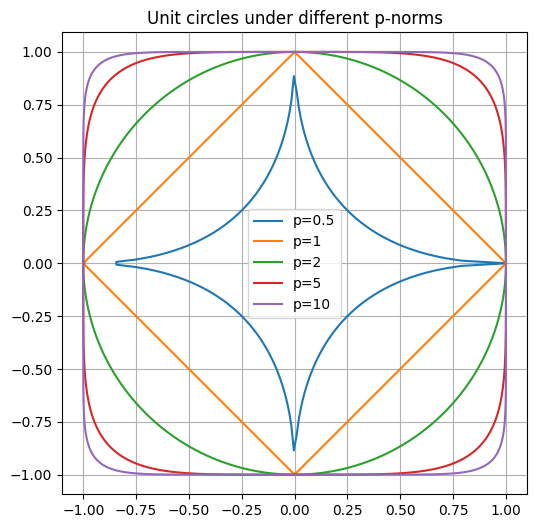

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def unit_circle_pnorm(p, num_points=400):
    theta = np.linspace(0, 2*np.pi, num_points)
    x = np.cos(theta)
    y = np.sin(theta)
    scale = (np.abs(x)**p + np.abs(y)**p)**(1/p)
    return x/scale, y/scale

ps = [0.5, 1, 2, 5, 10]
plt.figure(figsize=(6,6))
for p in ps:
    x, y = unit_circle_pnorm(p)
    plt.plot(x, y, label=f'p={p}')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.title('Unit circles under different p-norms')
plt.show()

**Theorem (equivalence of norms in finite dimensions):** The vector space $X$ is finite dimensional if and only is any two norms on it, say  $\| \cdot \|_1$ and $\| \cdot \|_2$, are equivalent, meaning that there exist constants $c_1, c_2 > 0$ such that for all $x \in X$:

$$
c_1 \|x\|_1 \leq \|x\|_2 \leq c_2 \|x\|_1.
$$

**Corollary:** In finite-dimensional vector spaces, all norms induce the same topology, meaning that notions such as convergence and continuity do not depend on the choice of norm.


#### Distance Measures in AI: An Overview

| AI Area / Task                        | Metric / Norm / Distance        | Why Important / Motivation |
|---------------------------------------|--------------------------------|----------------------------|
| Regression                             | $\ell_2$, $\ell_1$, $\ell_\infty$ | Measures error, defines loss |
| Classification                         | Cross-entropy (KL divergence)  | Quantifies difference between class probabilities |
| Regularization                          | $\|w\|_2$, $\|w\|_1$      | Simplifies model, prevents overfitting |
| k-NN / similarity-based methods        | Euclidean, cosine similarity    | Decisions based on "closeness" |
| Clustering (k-means, hierarchical)     | Euclidean, Mahalanobis         | Determines cluster assignments |
| Embedding / contrastive learning       | Cosine similarity, Euclidean   | "Similar close, different far" in latent space |
| Generative models (GAN, VAE)           | KL, JS, **Wasserstein distance**   | **Compare distributions**, pushforward mapping |
| Anomaly detection                       | Euclidean, Mahalanobis         | Detect outliers from normal patterns |
| Reinforcement learning                  | Sup-norm ($\ell_\infty$)    | Value function convergence, contraction guarantees |
| Adversarial robustness                  | $\ell_\infty, \ell_2$       | Sensitivity to small input perturbations |
| Metric learning / Siamese networks      | Learnable distance $d_\theta$ | Separate similar vs. dissimilar samples |
| Graph Neural Networks                   | Euclidean / learned distances  | Node aggregation, neighborhood weighting |
| Self-supervised / SimCLR                | Cosine similarity, dot-product | Contrastive loss, embedding learning |
| Manifold learning / t-SNE, UMAP         | High-dimensional Euclidean     | Preserve topology in low-dimensional space |
| Bayesian inference / Variational Inference | KL divergence, Wasserstein   | Compare distributions, ELBO optimization |
| Sequence modeling / Attention           | Cosine, dot-product            | Token relevance, weighting in sequences |
| Federated learning                       | Weight space: $\|w_i-w_j\|$ | Compare models for aggregation |
| Meta-learning                            | Task similarity (Euclidean, cosine) | Fast adaptation, transfer learning |
| Explainable AI                           | Input-output sensitivity ($\|x-x'\|$) | Model interpretation, feature importance |
